# 1. Data Inspection & Cleaning

Before performing exploratory analysis or model development, it is essential to understand the structure and quality of the dataset.

The objectives of this section are:

- Load and inspect the dataset
- Understand its dimensions and feature types
- Identify missing values and hidden missing values
- Detect duplicate records
- Remove unnecessary columns
- Prepare the dataset for further analysis

In [1]:
#@title Imports

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

In [2]:
#@title Initial inspection

df = pd.read_csv("cs-training.csv")

print("Dataset Loaded Successfully.")

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

display(df.head())

df.info()

display(df.describe().T)

display(df.dtypes.to_frame(name="Data Type"))

object_cols = df.select_dtypes(include="object").columns.tolist()

if len(object_cols) == 0:
    print("✅ No object-type columns found.")
else:
    print("⚠ Object columns detected:")
    display(object_cols)

for col in object_cols:

    print("="*50)
    print(col)
    print(df[col].value_counts(dropna=False).head(15))

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum()/len(df)*100).round(2)
})

missing = missing[missing["Missing Count"]>0]

display(missing)

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

df.drop(columns=["Unnamed: 0"], inplace=True)

print("Unnamed: 0 column removed.")

print(df.shape)

display(df.head())

Dataset Loaded Successfully.
Number of Rows    : 150000
Number of Columns : 12


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
1,2,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
2,3,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
3,4,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
4,5,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,150000.00,75000.50,43301.41,1.00,37500.75,75000.50,112500.25,150000.00
SeriousDlqin2yrs,150000.00,0.07,0.25,0.00,0.00,0.00,0.00,1.00
RevolvingUtilizationOfUnsecuredLines,150000.00,6.05,249.76,0.00,0.03,0.15,0.56,50708.00
age,150000.00,52.30,14.77,0.00,41.00,52.00,63.00,109.00
NumberOfTime30-59DaysPastDueNotWorse,150000.00,0.42,4.19,0.00,0.00,0.00,0.00,98.00
DebtRatio,150000.00,353.01,2037.82,0.00,0.18,0.37,0.87,329664.00
MonthlyIncome,120269.00,6670.22,14384.67,0.00,3400.00,5400.00,8249.00,3008750.00
NumberOfOpenCreditLinesAndLoans,150000.00,8.45,5.15,0.00,5.00,8.00,11.00,58.00
NumberOfTimes90DaysLate,150000.00,0.27,4.17,0.00,0.00,0.00,0.00,98.00
NumberRealEstateLoansOrLines,150000.00,1.02,1.13,0.00,0.00,1.00,2.00,54.00


,Data Type
Unnamed: 0,int64
SeriousDlqin2yrs,int64
RevolvingUtilizationOfUnsecuredLines,float64
age,int64
NumberOfTime30-59DaysPastDueNotWorse,int64
DebtRatio,float64
MonthlyIncome,float64
NumberOfOpenCreditLinesAndLoans,int64
NumberOfTimes90DaysLate,int64
NumberRealEstateLoansOrLines,int64


✅ No object-type columns found.


,Missing Count,Missing %
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


Duplicate Rows : 0
Unnamed: 0 column removed.
(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
1,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
2,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
3,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
4,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00


In [3]:
data_dictionary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

display(data_dictionary)

,Feature,Data Type,Missing Values,Unique Values
0,SeriousDlqin2yrs,int64,0,2
1,RevolvingUtilizationOfUnsecuredLines,float64,0,125728
2,age,int64,0,86
3,NumberOfTime30-59DaysPastDueNotWorse,int64,0,16
4,DebtRatio,float64,0,114194
5,MonthlyIncome,float64,29731,13594
6,NumberOfOpenCreditLinesAndLoans,int64,0,58
7,NumberOfTimes90DaysLate,int64,0,19
8,NumberRealEstateLoansOrLines,int64,0,28
9,NumberOfTime60-89DaysPastDueNotWorse,int64,0,13


# Exploratory Data Analysis (EDA)

In [4]:
#@title Feature Skewness
skewness = pd.DataFrame({
    "Skewness": df.skew().sort_values(ascending=False)
})

display(skewness)

,Skewness
MonthlyIncome,114.04
RevolvingUtilizationOfUnsecuredLines,97.63
DebtRatio,95.16
NumberOfTime60-89DaysPastDueNotWorse,23.33
NumberOfTimes90DaysLate,23.09
NumberOfTime30-59DaysPastDueNotWorse,22.60
NumberRealEstateLoansOrLines,3.48
SeriousDlqin2yrs,3.47
NumberOfDependents,1.59
NumberOfOpenCreditLinesAndLoans,1.22


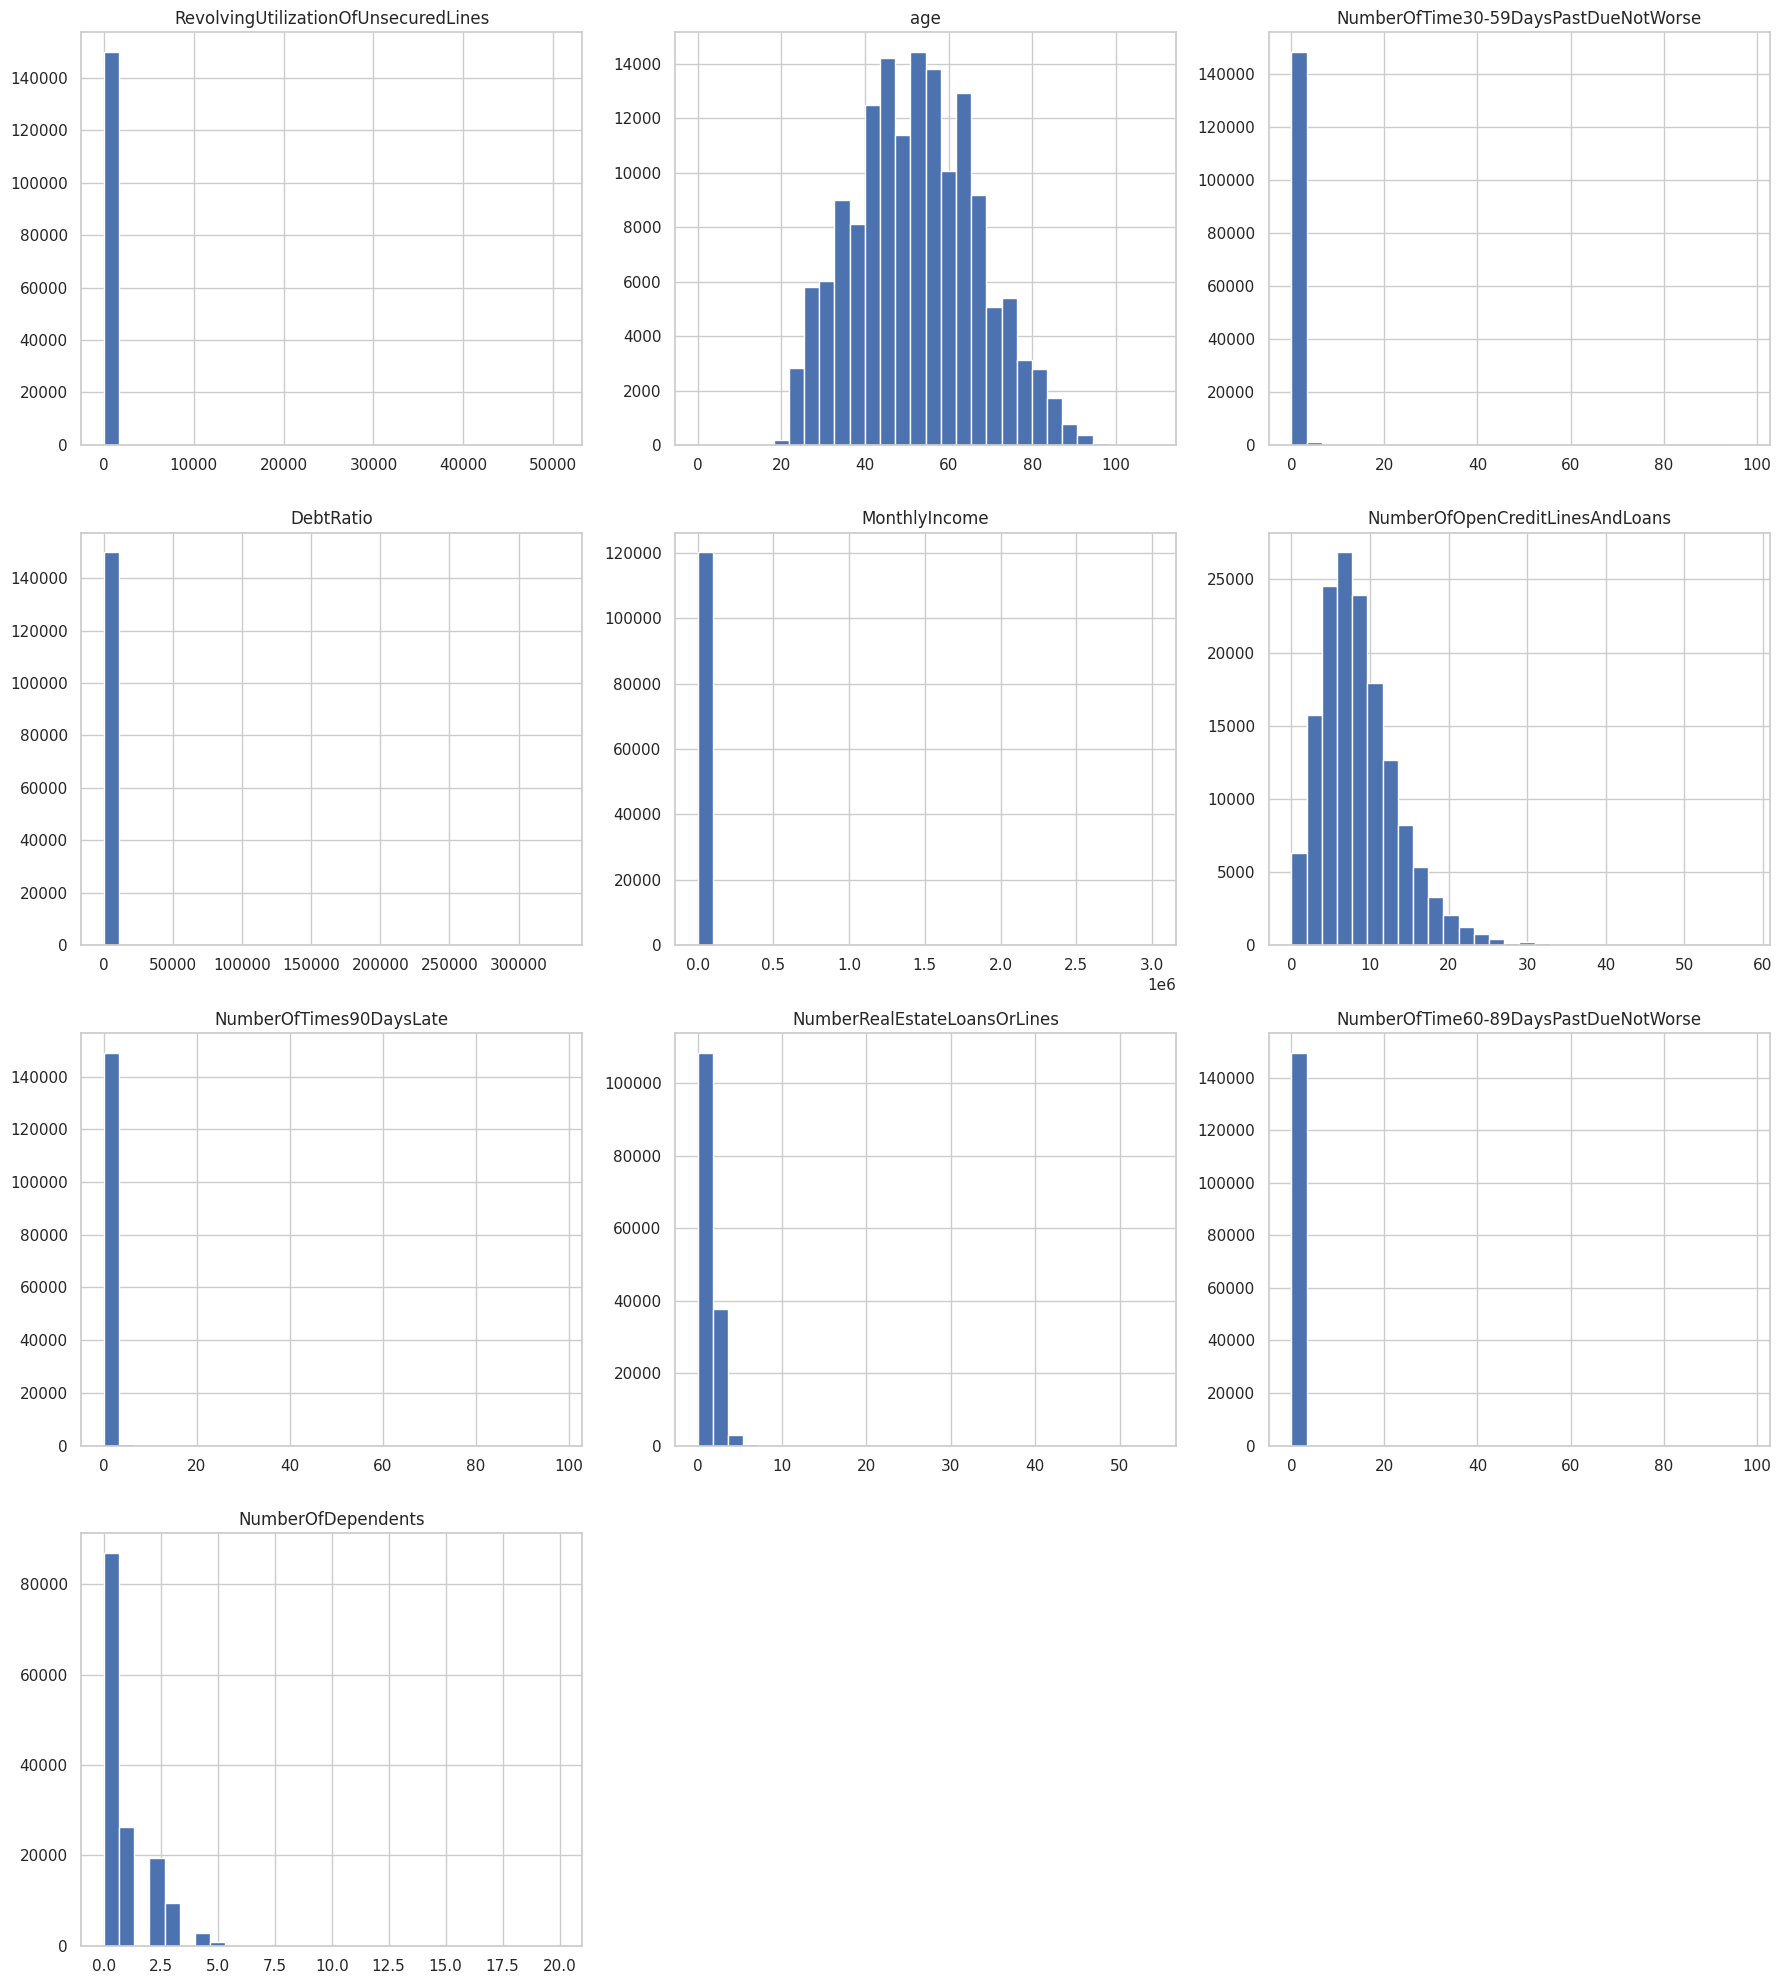

In [5]:
#@title Histograms of Numerical Features

num_cols = df.columns.drop("SeriousDlqin2yrs")

n_cols = 3
n_rows = int(np.ceil(len(num_cols)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    ax.hist(df[col].dropna(), bins=30)
    ax.set_title(col)

for ax in axes[len(num_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

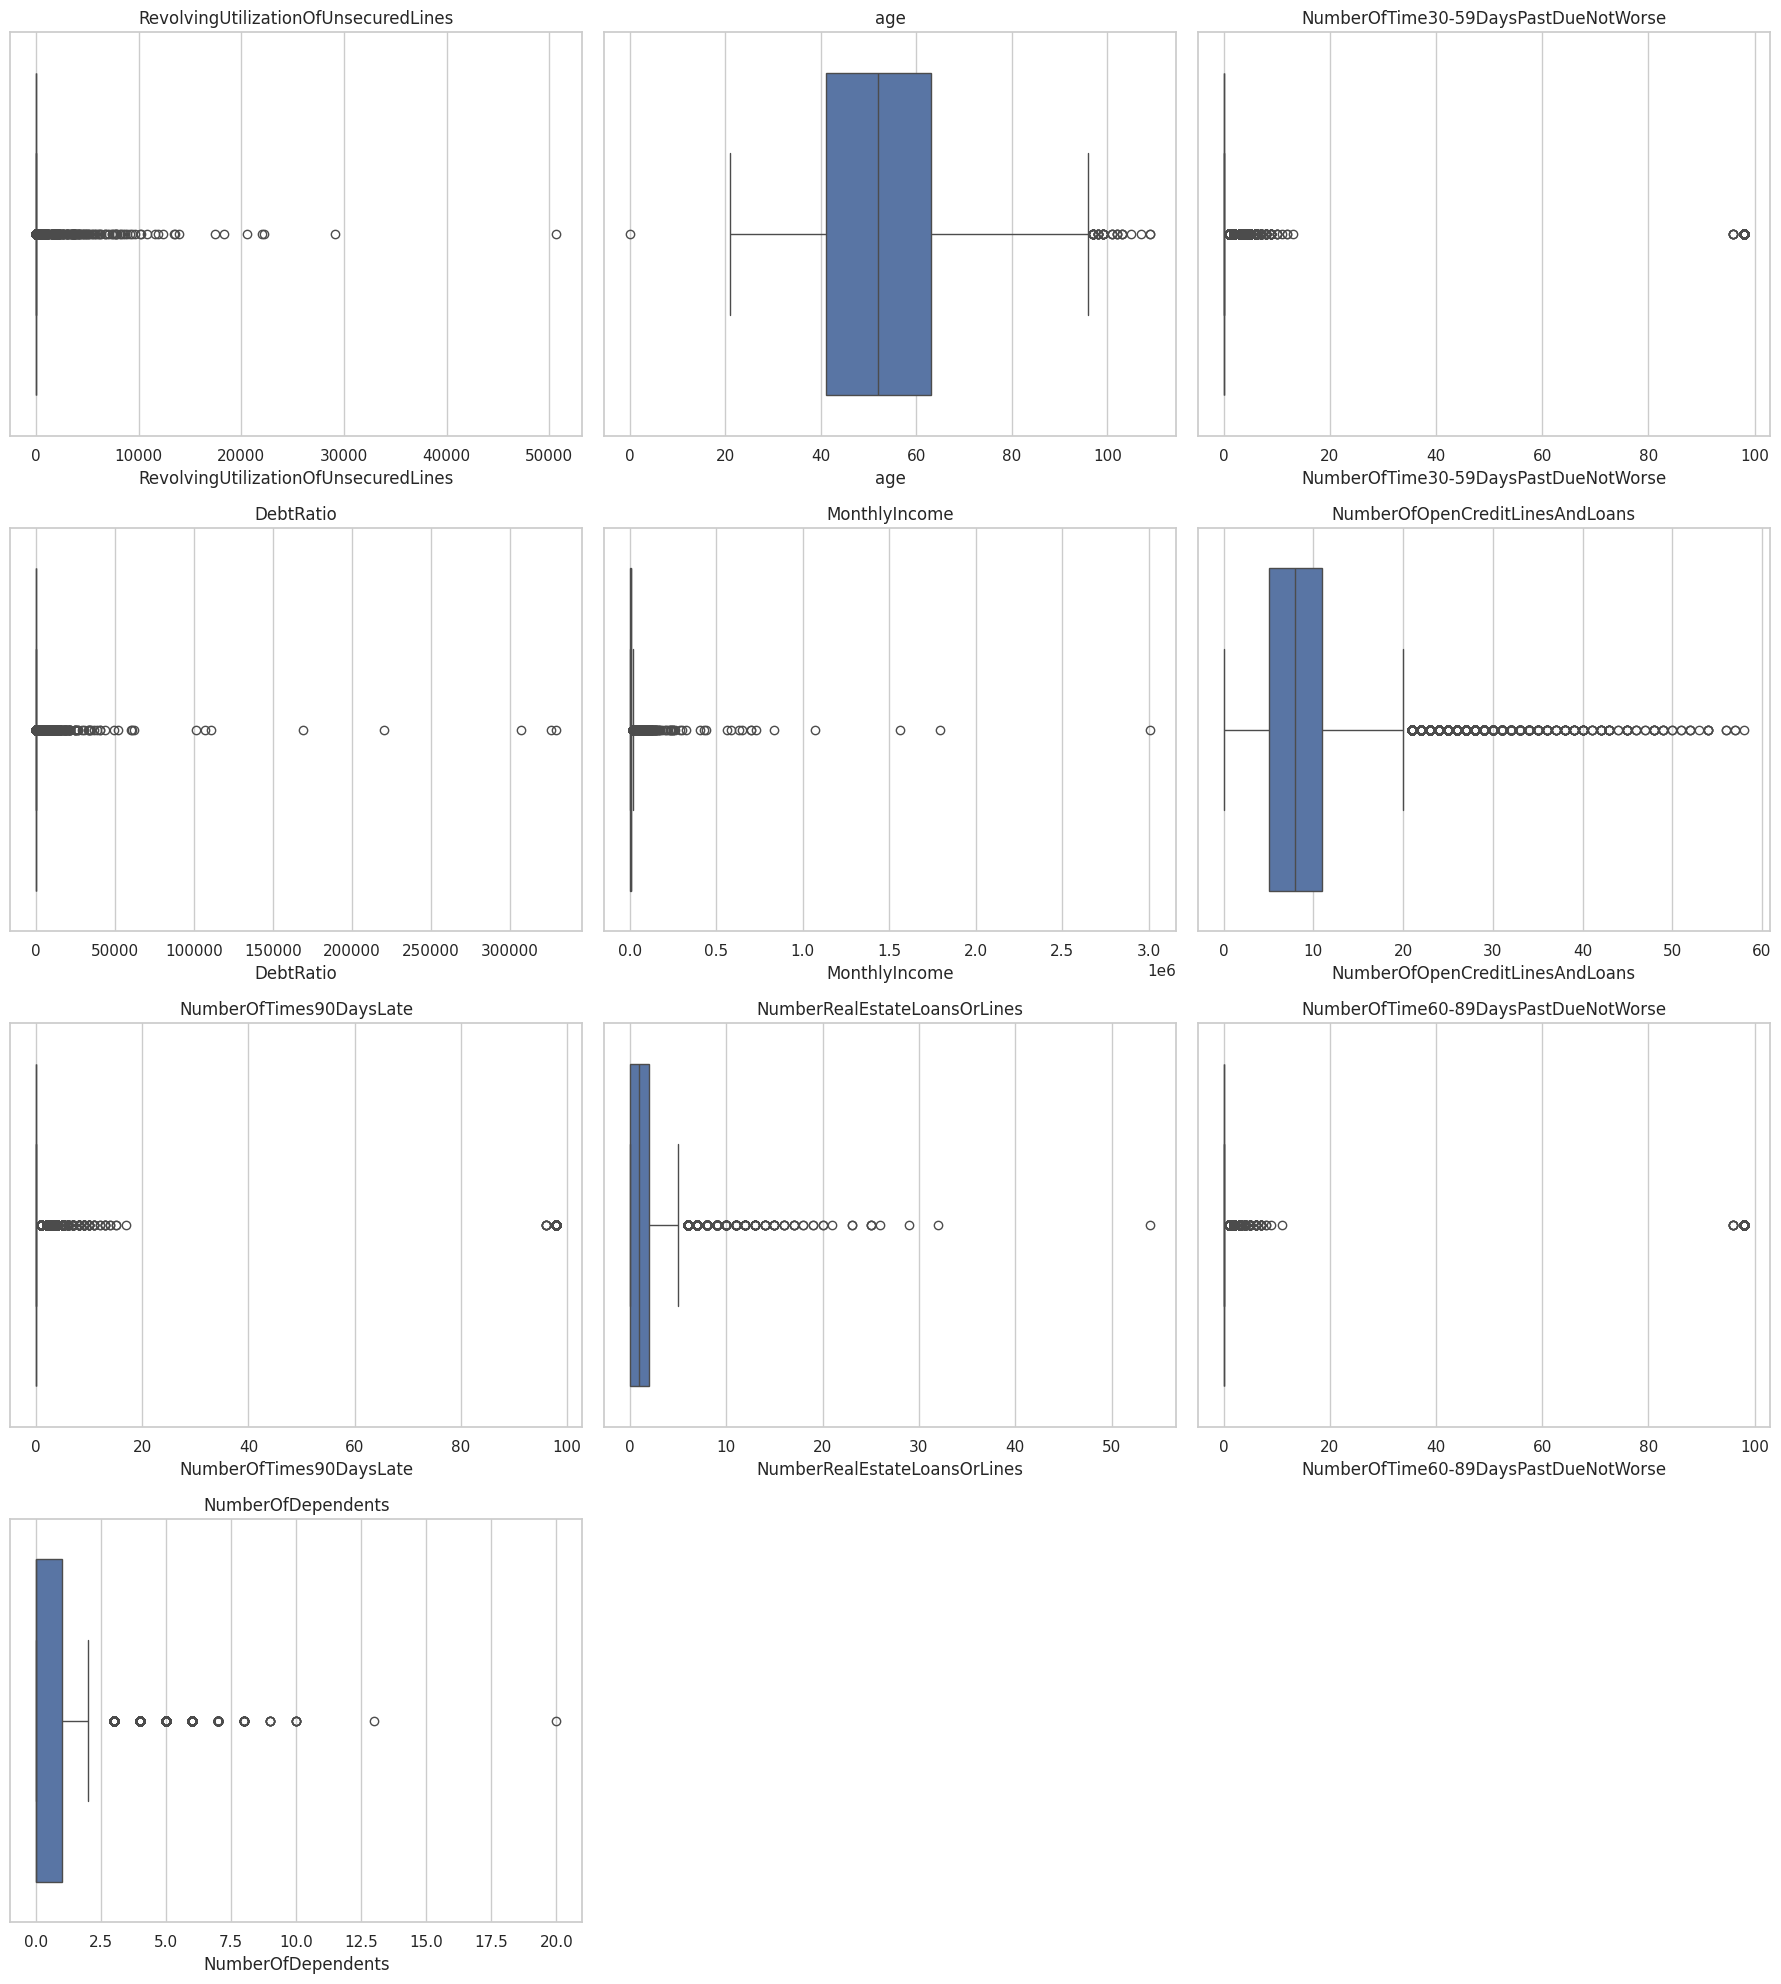

In [6]:
#@title Boxplots of Numerical Features

num_cols = df.columns.drop("SeriousDlqin2yrs")

n_cols = 3
n_rows = int(np.ceil(len(num_cols)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

for ax in axes[len(num_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

In [7]:
#@title Missing Value Distribution

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean()*100).round(2)
})

display(missing[missing["Missing Values"]>0])

,Missing Values,Percentage
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


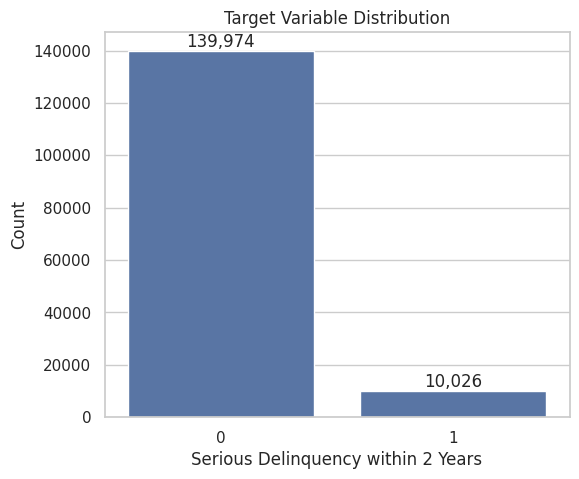

,Percentage
SeriousDlqin2yrs,
0,93.32
1,6.68


In [8]:
#@title Target Variable Distribution

plt.figure(figsize=(6,5))

ax = sns.countplot(
    x="SeriousDlqin2yrs",
    data=df
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x()+p.get_width()/2,
         p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Target Variable Distribution")
plt.xlabel("Serious Delinquency within 2 Years")
plt.ylabel("Count")

plt.show()

display(
    (df["SeriousDlqin2yrs"]
     .value_counts(normalize=True)
     .mul(100)
     .round(2)
     .rename("Percentage"))
)

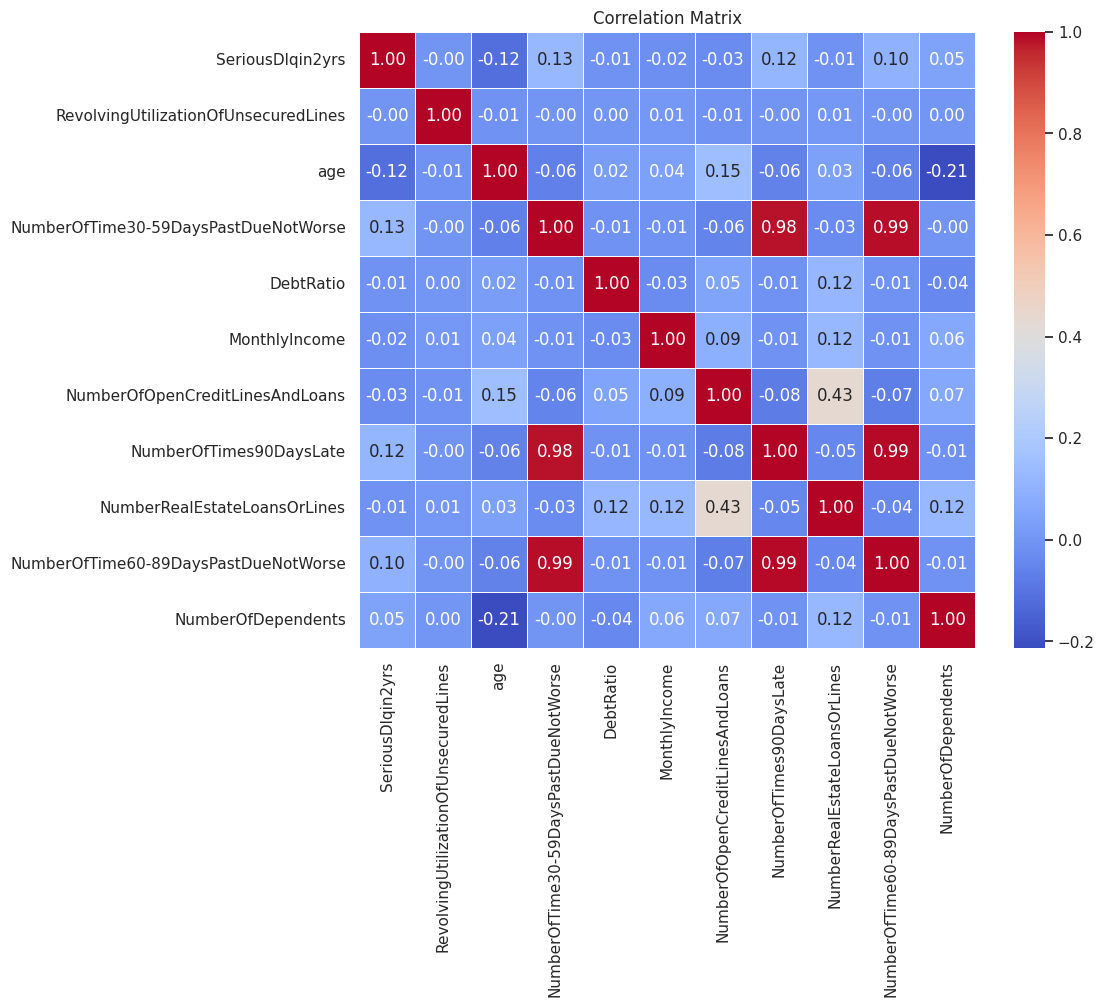

In [9]:
#@title Correlation Heatmap

plt.figure(figsize=(10, 8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

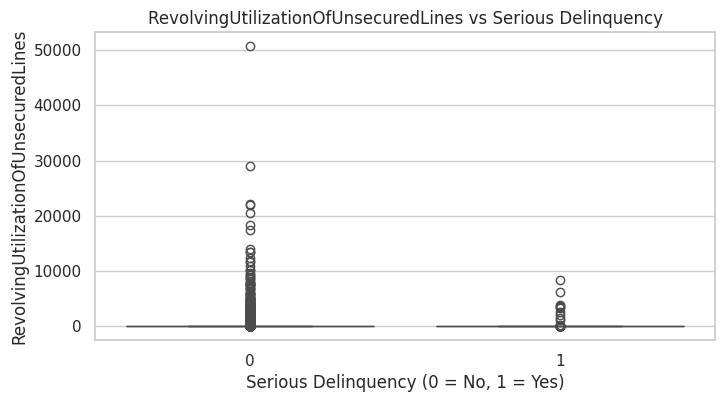

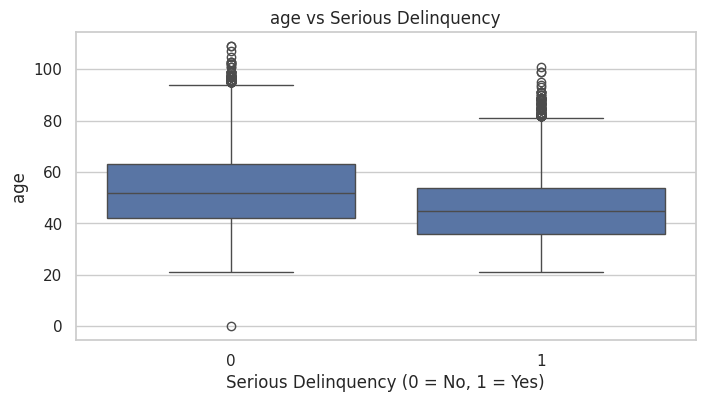

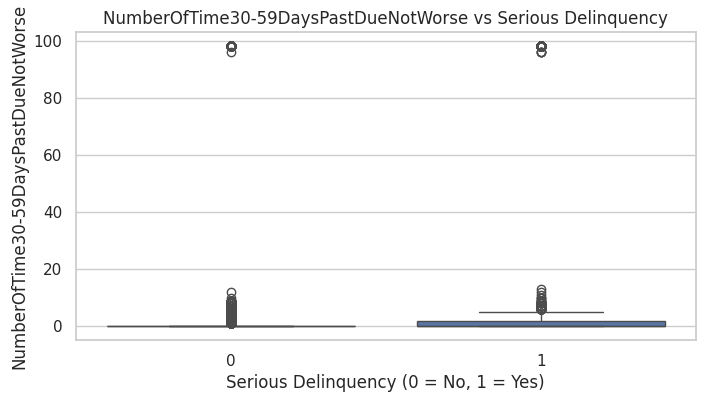

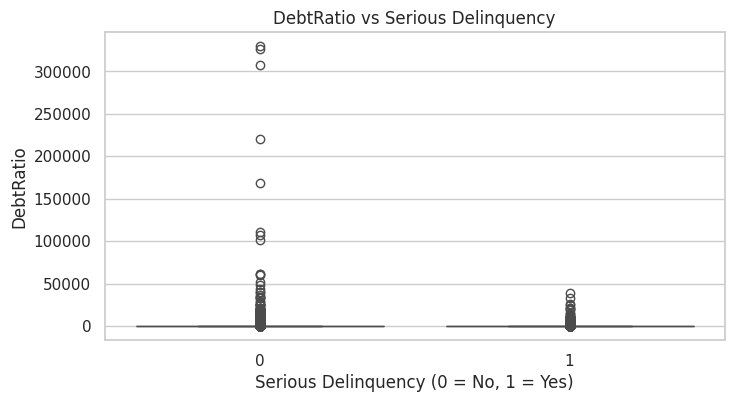

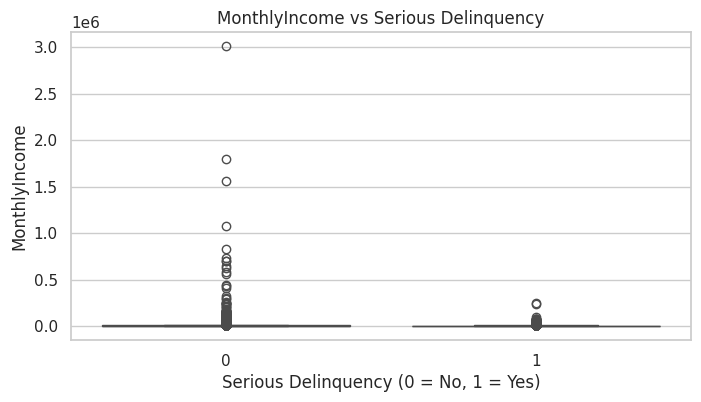

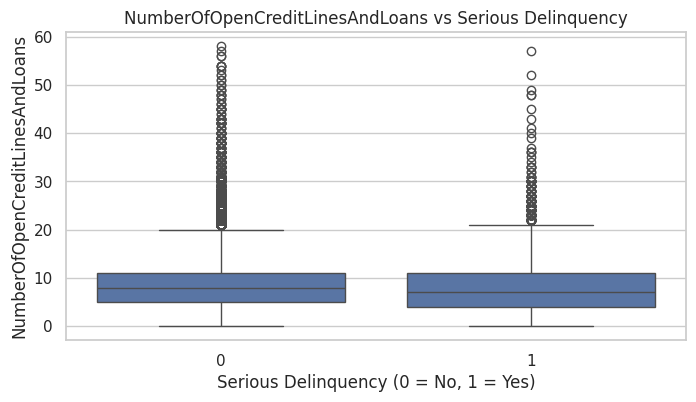

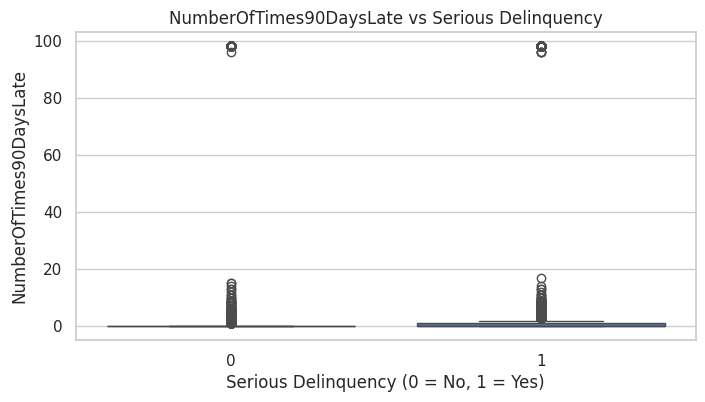

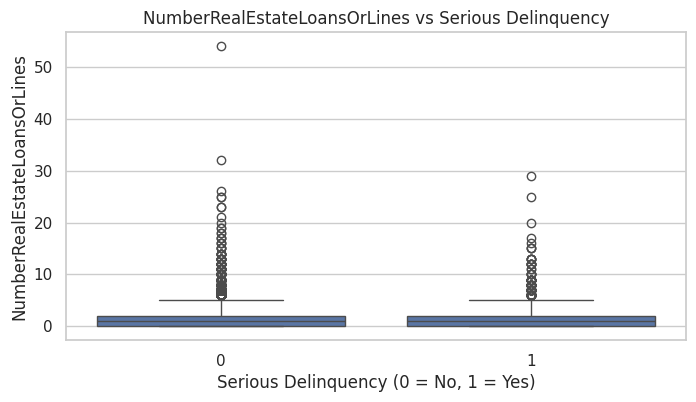

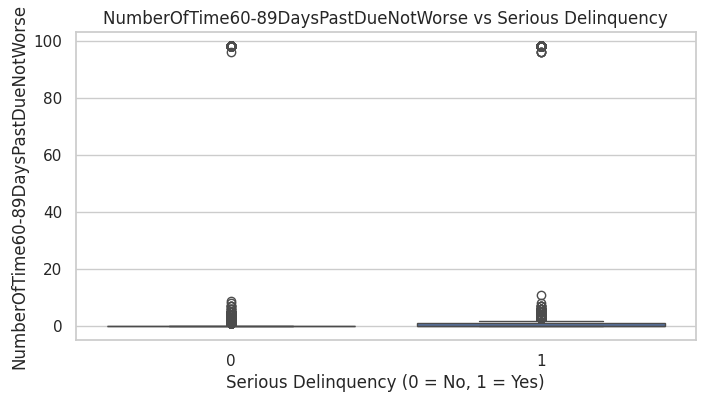

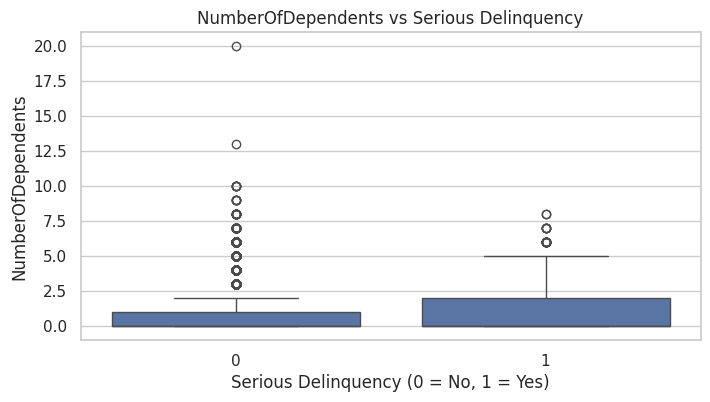

In [10]:
#@title Feature vs Target Boxplots

features = [col for col in df.columns if col != "SeriousDlqin2yrs"]

for feature in features:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=df,
        x="SeriousDlqin2yrs",
        y=feature
    )

    plt.title(f"{feature} vs Serious Delinquency")
    plt.xlabel("Serious Delinquency (0 = No, 1 = Yes)")
    plt.ylabel(feature)

    plt.show()

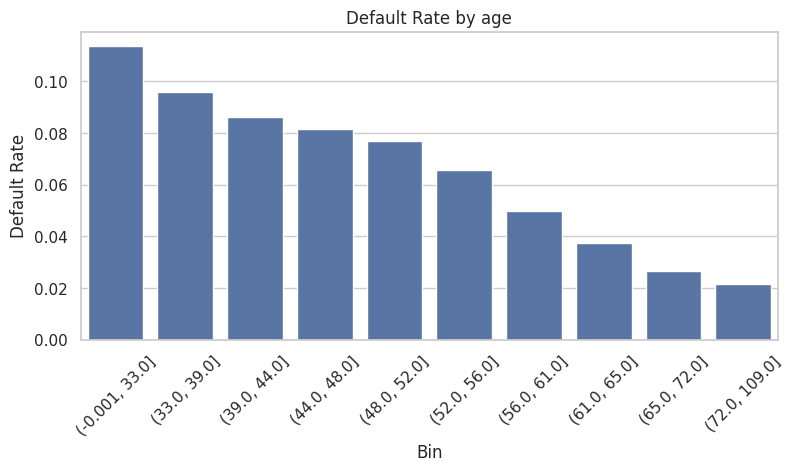

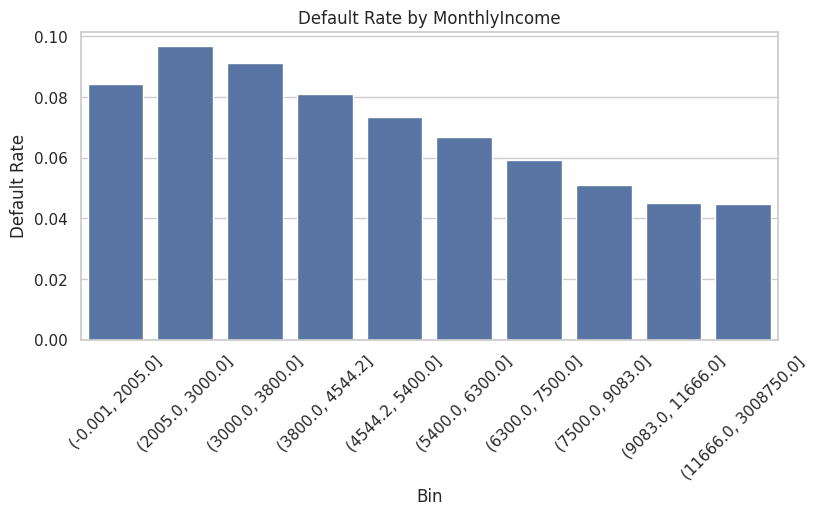

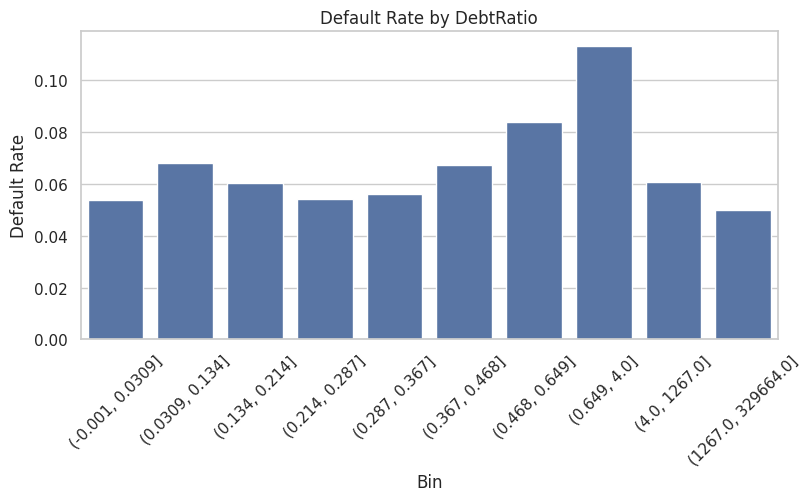

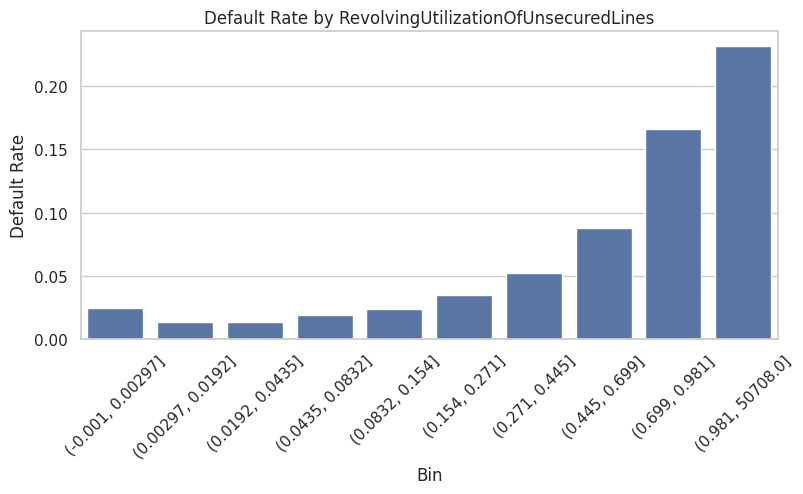

In [11]:
#@title Default Rate by Feature (Binned)

features = [
    "age",
    "MonthlyIncome",
    "DebtRatio",
    "RevolvingUtilizationOfUnsecuredLines"
]

for feature in features:

    temp = df[[feature, "SeriousDlqin2yrs"]].copy()

    temp["Bin"] = pd.qcut(
        temp[feature],
        q=10,
        duplicates="drop"
    )

    summary = (
        temp.groupby("Bin")["SeriousDlqin2yrs"]
            .mean()
            .reset_index()
    )

    plt.figure(figsize=(9,4))

    sns.barplot(
        data=summary,
        x="Bin",
        y="SeriousDlqin2yrs"
    )

    plt.xticks(rotation=45)
    plt.ylabel("Default Rate")
    plt.title(f"Default Rate by {feature}")

    plt.show()

In [12]:
#@title Correlation with Target

corr_target = (
    df.corr()["SeriousDlqin2yrs"]
      .drop("SeriousDlqin2yrs")
      .sort_values(key=abs, ascending=False)
)

display(corr_target.to_frame("Correlation"))

,Correlation
NumberOfTime30-59DaysPastDueNotWorse,0.13
NumberOfTimes90DaysLate,0.12
age,-0.12
NumberOfTime60-89DaysPastDueNotWorse,0.10
NumberOfDependents,0.05
NumberOfOpenCreditLinesAndLoans,-0.03
MonthlyIncome,-0.02
DebtRatio,-0.01
NumberRealEstateLoansOrLines,-0.01
RevolvingUtilizationOfUnsecuredLines,-0.00


# Data Preparation/Preprocessing

The preprocessing pipeline was designed based on the findings from the exploratory data analysis (EDA).

Key observations from EDA:

- The target variable is highly imbalanced (≈93:7).
- MonthlyIncome contains approximately 20% missing values.
- NumberOfDependents contains approximately 2.6% missing values.
- Several numerical features exhibit extreme right skewness.
- No duplicate records were found.
- All features are numerical.
- Features exist on different scales.
- Logistic Regression requires scaling and complete data.
- Random Forest requires complete data but is scale-invariant.
- XGBoost natively handles missing values and is insensitive to feature scaling.

In [13]:
#@title Separate Features and Target

X = df.drop(columns=["SeriousDlqin2yrs"])
y = df["SeriousDlqin2yrs"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Feature Matrix Shape : (150000, 10)
Target Shape         : (150000,)


In [14]:
#@title Stratified Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (120000, 10)
Testing Set  : (30000, 10)


In [15]:
#@title Verify Target Distribution After Split

print("Training Target Distribution (%)")
display(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print()

print("Testing Target Distribution (%)")
display(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training Target Distribution (%)


,proportion
SeriousDlqin2yrs,
0,93.32
1,6.68



Testing Target Distribution (%)


,proportion
SeriousDlqin2yrs,
0,93.32
1,6.68


In [16]:
#@title Create Missing Value Indicator Features

X_train["IncomeMissing"] = (
    X_train["MonthlyIncome"]
    .isna()
    .astype(int)
)

X_test["IncomeMissing"] = (
    X_test["MonthlyIncome"]
    .isna()
    .astype(int)
)

X_train["DependentsMissing"] = (
    X_train["NumberOfDependents"]
    .isna()
    .astype(int)
)

X_test["DependentsMissing"] = (
    X_test["NumberOfDependents"]
    .isna()
    .astype(int)
)

print("Missing indicator features created.")

Missing indicator features created.


In [17]:
#@title Median Imputation (Training Statistics Only)

monthly_income_median = X_train["MonthlyIncome"].median()
dependents_median = X_train["NumberOfDependents"].median()

X_train["MonthlyIncome"] = X_train["MonthlyIncome"].fillna(
    monthly_income_median
)

X_test["MonthlyIncome"] = X_test["MonthlyIncome"].fillna(
    monthly_income_median
)

X_train["NumberOfDependents"] = X_train["NumberOfDependents"].fillna(
    dependents_median
)

X_test["NumberOfDependents"] = X_test["NumberOfDependents"].fillna(
    dependents_median
)

print("Median imputation completed.")

Median imputation completed.


In [18]:
#@title Verify Missing Values After Imputation

print("Training Missing Values")

display(X_train.isnull().sum())

print()

print("Testing Missing Values")

display(X_test.isnull().sum())

Training Missing Values


,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0
NumberOfDependents,0



Testing Missing Values


,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0
NumberOfDependents,0


In [19]:
#@title Feature Skewness Before Transformation

skew_before = X_train.skew().sort_values(ascending=False)

display(
    pd.DataFrame({
        "Skewness Before": skew_before
    })
)

,Skewness Before
MonthlyIncome,136.58
RevolvingUtilizationOfUnsecuredLines,100.54
DebtRatio,99.14
NumberOfTime60-89DaysPastDueNotWorse,23.39
NumberOfTimes90DaysLate,23.16
NumberOfTime30-59DaysPastDueNotWorse,22.66
DependentsMissing,5.95
NumberRealEstateLoansOrLines,3.75
NumberOfDependents,1.64
IncomeMissing,1.52


In [20]:
#@title Skewness After Log Transformation

features = [
    "MonthlyIncome",
    "DebtRatio",
    "RevolvingUtilizationOfUnsecuredLines"
]

comparison = []

for feature in features:

    comparison.append({
        "Feature": feature,
        "Before": X_train[feature].skew(),
        "After log1p": np.log1p(X_train[feature]).skew()
    })

comparison = pd.DataFrame(comparison)

display(comparison)

,Feature,Before,After log1p
0,MonthlyIncome,136.58,-4.93
1,DebtRatio,99.14,1.75
2,RevolvingUtilizationOfUnsecuredLines,100.54,11.77


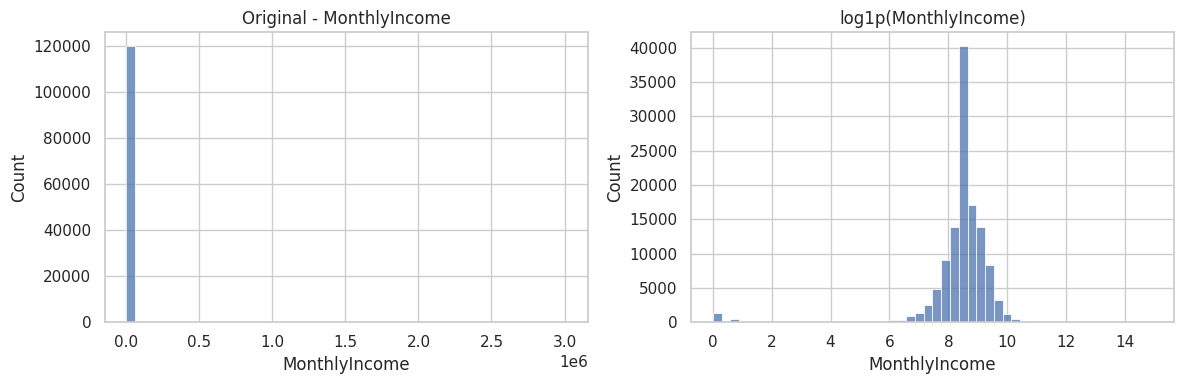

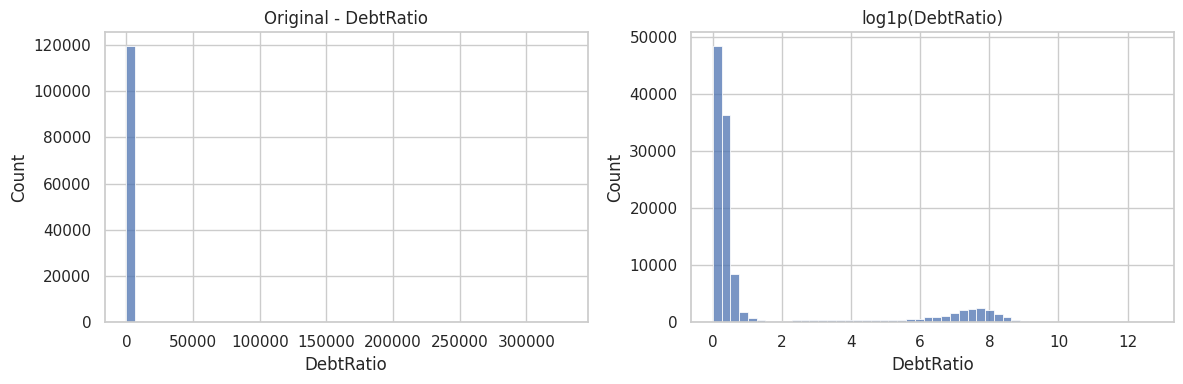

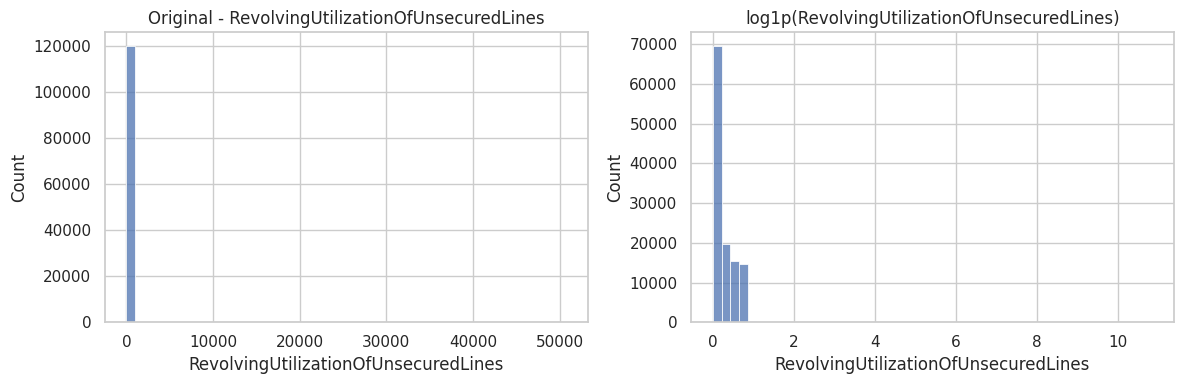

In [21]:
#@title Original vs Log-Transformed Distributions

features = [
    "MonthlyIncome",
    "DebtRatio",
    "RevolvingUtilizationOfUnsecuredLines"
]

for feature in features:

    fig, axes = plt.subplots(1,2, figsize=(12,4))

    sns.histplot(
        X_train[feature],
        bins=50,
        ax=axes[0]
    )

    axes[0].set_title(f"Original - {feature}")

    sns.histplot(
        np.log1p(X_train[feature]),
        bins=50,
        ax=axes[1]
    )

    axes[1].set_title(f"log1p({feature})")

    plt.tight_layout()
    plt.show()

In [22]:
#@title Create Model-Specific Feature Sets

X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

X_train_rf = X_train.copy()
X_test_rf = X_test.copy()

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

print("Feature sets created.")

Feature sets created.


In [23]:
#@title Apply Log Transformation (Logistic Regression Only)

log_features = [
    "MonthlyIncome",
    "DebtRatio",
    "RevolvingUtilizationOfUnsecuredLines"
]

for feature in log_features:

    X_train_lr[feature] = np.log1p(X_train_lr[feature])
    X_test_lr[feature] = np.log1p(X_test_lr[feature])

print("Log transformation completed.")

Log transformation completed.


In [24]:
#@title Standardize Features for Logistic Regression

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_lr = pd.DataFrame(
    scaler.fit_transform(X_train_lr),
    columns=X_train_lr.columns,
    index=X_train_lr.index
)

X_test_lr = pd.DataFrame(
    scaler.transform(X_test_lr),
    columns=X_test_lr.columns,
    index=X_test_lr.index
)

print("Feature scaling completed.")

Feature scaling completed.


In [25]:
#@title Final Dataset Summary

print("Logistic Regression")
print(X_train_lr.shape, X_test_lr.shape)

print()

print("Random Forest")
print(X_train_rf.shape, X_test_rf.shape)

print()

print("XGBoost")
print(X_train_xgb.shape, X_test_xgb.shape)

Logistic Regression
(120000, 12) (30000, 12)

Random Forest
(120000, 12) (30000, 12)

XGBoost
(120000, 12) (30000, 12)


# Model Training and Evaluation

In [61]:
#@title XGBoost

from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    log_loss,
    brier_score_loss
)

import numpy as np

# -----------------------
# Train Model
# -----------------------

xgb = XGBClassifier(

    objective="binary:logistic",

    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=13,

    eval_metric="logloss",

    random_state=42

)

xgb.fit(X_train, y_train)

# -----------------------
# Predict Probabilities
# -----------------------

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# -----------------------
# Best Threshold
# -----------------------

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_xgb
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
) / (
    precision[:-1] + recall[:-1] + 1e-10
)

best_threshold_xgb = thresholds[np.argmax(f1_scores)]

print(f"Best Threshold : {best_threshold_xgb:.4f}")
print(f"Best F1        : {f1_scores.max():.4f}")

# -----------------------
# Final Predictions
# -----------------------

y_pred_xgb = (
    y_prob_xgb >= best_threshold_xgb
).astype(int)

# -----------------------
# Metrics
# -----------------------

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()

specificity = tn / (tn + fp)

print("=" * 45)
print("XGBoost Performance")
print("=" * 45)

print(f"Accuracy      : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision     : {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall        : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"Specificity   : {specificity:.4f}")
print(f"F1 Score      : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"MCC           : {matthews_corrcoef(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_prob_xgb):.4f}")
print(f"Log Loss      : {log_loss(y_test, y_prob_xgb):.4f}")
print(f"Brier Score   : {brier_score_loss(y_test, y_prob_xgb):.4f}")

Best Threshold : 0.7479
Best F1        : 0.4481
XGBoost Performance
Accuracy      : 0.9168
Precision     : 0.4026
Recall        : 0.5052
Specificity   : 0.9463
F1 Score      : 0.4481
MCC           : 0.4068
ROC-AUC       : 0.8657
PR-AUC        : 0.3968
Log Loss      : 0.4004
Brier Score   : 0.1256


In [52]:
#@title Vanilla Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    log_loss,
    brier_score_loss
)

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train
lr.fit(X_train, y_train)

# Predict
# y_prob = lr.predict_proba(X_test)[:, 1]
# y_pred = lr.predict(X_test)

# Predict probabilities
y_prob = lr.predict_proba(X_test)[:, 1]

# Find threshold that maximizes F1
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
) / (
    precision[:-1] + recall[:-1] + 1e-10
)

best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Best Threshold : {best_threshold:.4f}")
print(f"Best F1        : {f1_scores.max():.4f}")

# Final predictions using custom threshold
y_pred = (y_prob >= best_threshold).astype(int)

# Metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("=" * 45)
print("Logistic Regression Performance")
print("=" * 45)

print(f"Accuracy      : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision     : {precision_score(y_test, y_pred):.4f}")
print(f"Recall        : {recall_score(y_test, y_pred):.4f}")
print(f"Specificity   : {specificity:.4f}")
print(f"F1 Score      : {f1_score(y_test, y_pred):.4f}")
print(f"MCC           : {matthews_corrcoef(y_test, y_pred):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_prob):.4f}")
print(f"Log Loss      : {log_loss(y_test, y_prob):.4f}")
print(f"Brier Score   : {brier_score_loss(y_test, y_prob):.4f}")

Best Threshold : 0.6234
Best F1        : 0.4011
Logistic Regression Performance
Accuracy      : 0.9132
Precision     : 0.3722
Recall        : 0.4349
Specificity   : 0.9475
F1 Score      : 0.4011
MCC           : 0.3559
ROC-AUC       : 0.8033
PR-AUC        : 0.3250
Log Loss      : 0.5700
Brier Score   : 0.1763


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    log_loss,
    brier_score_loss
)

import numpy as np

# -----------------------------
# Train Random Forest
# -----------------------------
rf = RandomForestClassifier(

    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1

)

rf.fit(X_train, y_train)

# -----------------------------
# Predict probabilities
# -----------------------------
y_prob_rf = rf.predict_proba(X_test)[:,1]

# -----------------------------
# Best Threshold
# -----------------------------
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_rf
)

f1_scores = (
    2*precision[:-1]*recall[:-1]
)/(precision[:-1]+recall[:-1]+1e-10)

best_threshold_rf = thresholds[np.argmax(f1_scores)]

print(f"Best Threshold : {best_threshold_rf:.4f}")
print(f"Best F1        : {f1_scores.max():.4f}")

# -----------------------------
# Final Predictions
# -----------------------------
y_pred_rf = (y_prob_rf >= best_threshold_rf).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test,y_pred_rf).ravel()

specificity = tn/(tn+fp)

print("="*45)
print("Random Forest Performance")
print("="*45)

print(f"Accuracy      : {accuracy_score(y_test,y_pred_rf):.4f}")
print(f"Precision     : {precision_score(y_test,y_pred_rf):.4f}")
print(f"Recall        : {recall_score(y_test,y_pred_rf):.4f}")
print(f"Specificity   : {specificity:.4f}")
print(f"F1 Score      : {f1_score(y_test,y_pred_rf):.4f}")
print(f"MCC           : {matthews_corrcoef(y_test,y_pred_rf):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test,y_prob_rf):.4f}")
print(f"PR-AUC        : {average_precision_score(y_test,y_prob_rf):.4f}")
print(f"Log Loss      : {log_loss(y_test,y_prob_rf):.4f}")
print(f"Brier Score   : {brier_score_loss(y_test,y_prob_rf):.4f}")

Best Threshold : 0.1833
Best F1        : 0.4185
Random Forest Performance
Accuracy      : 0.9031
Precision     : 0.3494
Recall        : 0.5217
Specificity   : 0.9304
F1 Score      : 0.4185
MCC           : 0.3767
ROC-AUC       : 0.8451
PR-AUC        : 0.3571
Log Loss      : 0.2233
Brier Score   : 0.0509


In [62]:
#@title Final Model Comparison

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],

    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ],

    "MCC": [
        matthews_corrcoef(y_test, y_pred),
        matthews_corrcoef(y_test, y_pred_rf),
        matthews_corrcoef(y_test, y_pred_xgb)
    ]

}).round(4)

comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,MCC
0,Logistic Regression,0.92,0.40,0.51,0.45,0.80,0.33,0.41
1,XGBoost,0.92,0.40,0.51,0.45,0.87,0.40,0.41
2,Random Forest,0.90,0.35,0.52,0.42,0.85,0.36,0.38


In [63]:
#@title High Confidence Analysis

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd
import numpy as np

thresholds = [0.60, 0.70, 0.80, 0.90, 0.95, 0.99]

models = {
    "Logistic Regression": y_prob,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb
}

rows = []

for model_name, probs in models.items():

    for conf in thresholds:

        # confidence = max(P(default), P(non-default))
        confidence = np.maximum(probs, 1 - probs)

        mask = confidence >= conf

        coverage = mask.mean()

        if mask.sum() == 0:
            continue

        y_true = y_test[mask]
        probs_conf = probs[mask]

        # predicted class
        y_pred = (probs_conf >= 0.5).astype(int)

        rows.append({

            "Model": model_name,
            "Confidence ≥": conf,
            "Coverage (%)": round(coverage*100,2),

            "Accuracy": round(
                accuracy_score(y_true,y_pred),4
            ),

            "Precision": round(
                precision_score(y_true,y_pred,zero_division=0),4
            ),

            "Recall": round(
                recall_score(y_true,y_pred,zero_division=0),4
            ),

            "F1": round(
                f1_score(y_true,y_pred,zero_division=0),4
            ),

            "ROC-AUC": round(
                roc_auc_score(y_true,probs_conf),4
            ) if len(np.unique(y_true))>1 else np.nan

        })

results = pd.DataFrame(rows)

display(results)

,Model,Confidence ≥,Coverage (%),Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.60,60.53,0.88,0.34,0.74,0.47,0.86
1,Logistic Regression,0.70,28.40,0.90,0.44,0.88,0.59,0.91
2,Logistic Regression,0.80,5.18,0.77,0.53,0.98,0.69,0.87
3,Logistic Regression,0.90,1.24,0.66,0.63,1.00,0.77,0.57
4,Logistic Regression,0.95,0.63,0.64,0.60,1.00,0.75,0.57
5,Logistic Regression,0.99,0.29,0.58,0.54,1.00,0.70,0.59
6,Random Forest,0.60,97.78,0.94,0.63,0.10,0.17,0.83
7,Random Forest,0.70,95.05,0.95,0.64,0.05,0.09,0.80
8,Random Forest,0.80,91.13,0.96,0.64,0.02,0.03,0.77
9,Random Forest,0.90,82.54,0.97,0.80,0.01,0.01,0.71


<Figure size 1000x600 with 0 Axes>

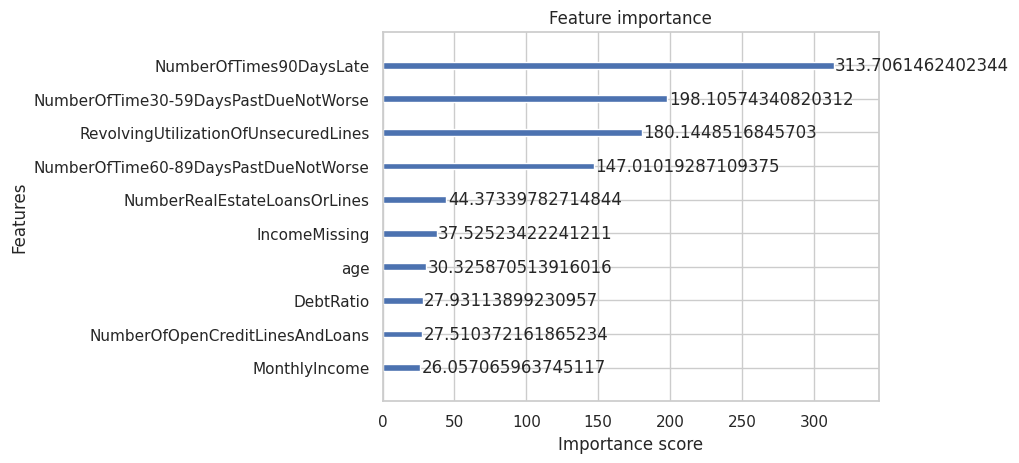

In [64]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plot_importance(
    xgb,
    importance_type="gain",
    max_num_features=10
)

plt.show()

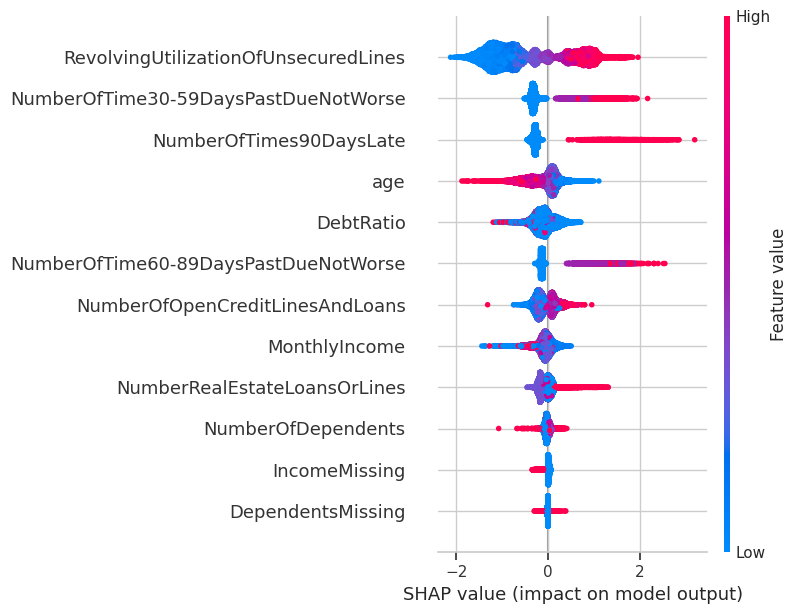

In [65]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

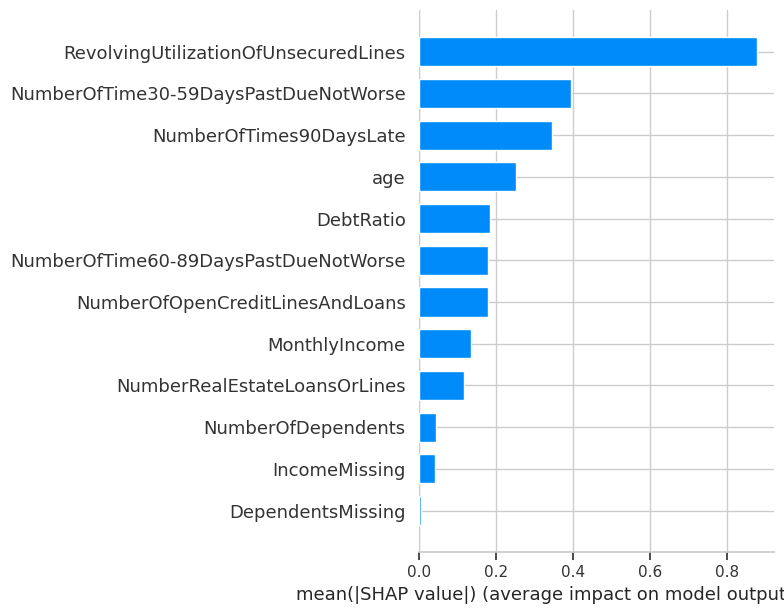

In [66]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)